In [13]:
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Load_bresast_cancer()

In [56]:
data = load_breast_cancer()
x = data.data
y = data.target


# Train model and model predic

In [57]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2)
model = MLPClassifier(hidden_layer_sizes=(8,8,8,8) ,max_iter=1000, random_state=0)
model.fit(X_train, Y_train)
y_predic = model.predict(X_test)
accuracy_score(Y_test, y_predic)


0.8859649122807017

In [58]:
f1_score(Y_test, y_predic, average='macro')

0.8811261730969759

In [59]:
f1_score(Y_test, y_predic, average='micro')

0.8859649122807017

In [60]:
confusion_matrix(Y_test, y_predic)

array([[39, 11],
       [ 2, 62]])

## หา f1_score ที่มากที่สุดก่อน ขั้นตอนนี้เพิ่มการหาค่า ACCURACY เพิ่มขึ้นมา

In [61]:
max_iter = [5,10,100,1000]
f1_result = {}
acc = {}

for i in max_iter:
    m = MLPClassifier(hidden_layer_sizes=(32, 32, 32, 32, 32, 32), max_iter=i, random_state=0)
    m.fit(X_train, Y_train)
    predicted = model.predict(X_test)
    f1 = f1_score(Y_test, predicted, average='macro')
    f1_result[i] = f1
    acc2 = accuracy_score(Y_test, predicted) 
    acc[i] = acc2

best_max_iter = max(f1_result, key=f1_result.get)
best_acc = max(acc, key=acc.get)
print(f"f1_score = {f1_result[best_max_iter]}")
print(f"Accuracy = {acc[best_acc]}")

C:\Users\piyaw\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\piyaw\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\piyaw\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


f1_score = 0.8811261730969759
Accuracy = 0.8859649122807017


## ส่วนนี้คือขั้นตอนการหา Thresholds เพื่อนำค่าที่คำนวณได้ไป Plot เป็นกราฟ ROC
- สูตรของการหา ROC --> TPR = TP / (TP + FN)
- อีกสูตร FPR = FP / (FP  TN)

## ขั้นตอนการทำ ROC graph (Best) กรอกเฉพาะ max_iter ที่ให้ผล F1 สูงสุด
- train model ด้วย max_iter ที่มากที่สุด
- ใช้ model.predict_proba เพื่อได้ความน่าจะเป็น ที่แต่ละตัวอย่างเป็นคลาส 1
- ใช้ roc_curve เพื่อคำนวณ FPR, TPR ที่ทุกค่า Threshold
- ใช้ auc เพื่อคำนวรพื้นที่ใต้กราฟ
- plot เส้นทะแยงด้วย matplotlib

In [62]:
best_model = MLPClassifier(hidden_layer_sizes=(32, 32, 32, 32, 32, 32), max_iter=best_max_iter, random_state=0)
best_model.fit(X_train, Y_train)

y_score = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(Y_test, y_score)

roc_auc = auc(fpr, tpr)
print(roc_auc)


0.9634375


C:\Users\piyaw\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(


## วิธีการสร้างกราฟ
1. กำหนด Threshold ต่ำๆ สร้าง confusion matrix
2. คำนวณ sensitivity (True Positive Rate)
3. คำนวณ 1-Specificity (False Positive Rate)
5. plot graph

## การพล็อตกราฟ
- ROC ใช้ดูโมเดล แยก class 0 กับ 1 ได้ดีแค่ไหน ที่ทุกๆค่าของ  threshold ของความน่าจะเป็น
- แกน X = False Positive Rate (FPR) --> สัดส่วนที่ model ทำนายผิดว่าเป็น positive ทั้งที่ความจริงเป็น nagative
- แกน Y = True Positive Rate (TPR) --> สัดส่วนโมเดลจับ positive ได้ถูกต้อง
- เส้นทแยงมุม คือ โมเดลที่เดาสุ่ม ยิ่งเส้นโค้งของเรามากขึ้นไปทางซ้ายบนมากเท่าไรโมเดลยิ่งดี
- AUC (Area Under Curve) --> พื้นที่ใต้เส้น ROC ยิ่งใกล้ 1 ยิ่งดี 0.5คือแย่พอๆกับเดาสุ่ม

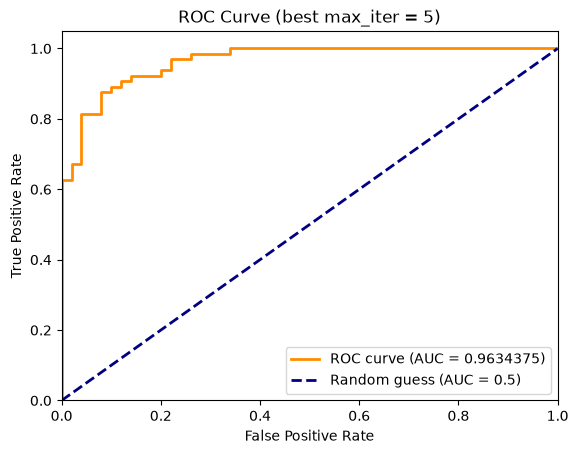

In [133]:
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange', lw = lw, label = f'ROC curve (AUC = {roc_auc})')
plt.plot([0, 1], [0, 1], color='navy', lw = lw, linestyle = '--', label = 'Random guess (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (best max_iter = {best_max_iter})')
plt.legend(loc = 'lower right')
plt.show() 

# Load_Digits

In [117]:
from sklearn.datasets import load_digits
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [66]:
data_d = load_digits() 
X1 = data_d.data
Y1 = data_d.target

# คำนวณค่า Accuracy , F1_score โดยการวนลูป

In [103]:
X1_train, X1_test, Y1_train, Y1_test = train_test_split(X1, Y1, test_size=0.20)

max_iter2 = [5,10,100,1000]
acc1 = {}
f1_result_macro = {}
f1_result_micro = {}
for i in max_iter2:
    model2 = MLPClassifier(hidden_layer_sizes=(32, 32, 32, 32, 32, 32),max_iter = i, random_state = 0)
    model2.fit(X1_train, Y1_train)
    model_pred = model2.predict(X1_test)
    acc2 = accuracy_score(Y1_test, model_pred)
    f1_macro = f1_score(Y1_test, model_pred, average = 'macro')
    f1_micro = f1_score(Y1_test, model_pred, average = 'micro')
    f1_result_macro[i] = f1_macro
    f1_result_micro[i] = f1_micro
    acc1[i] = acc2
    print(f"Accuracy = {acc1[i]}")
    print(f"F1_score_macro = {f1_result_macro[i]}")
    print(f"F1_score_micro = {f1_result_micro[i]}")

C:\Users\piyaw\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\piyaw\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy = 0.6777777777777778
F1_score_macro = 0.6280325588937803
F1_score_micro = 0.6777777777777778
Accuracy = 0.875
F1_score_macro = 0.868409487270956
F1_score_micro = 0.875
Accuracy = 0.9722222222222222
F1_score_macro = 0.9720154028774635
F1_score_micro = 0.9722222222222222
Accuracy = 0.9722222222222222
F1_score_macro = 0.9720154028774635
F1_score_micro = 0.9722222222222222


## หาค่า max_iter ที่ดีที่สุด และหา f1_score ที่ดีที่สุด

In [134]:
max_f1 = {}
for i in max_iter2:
    model2 = MLPClassifier(hidden_layer_sizes=(32, 32, 32, 32, 32, 32),max_iter = i, random_state = 0)
    model2.fit(X1_train, Y1_train)
    model_pred = model2.predict(X1_test)
    f1 = f1_score(Y1_test, model_pred, average='macro')
    max_f1[i] = f1
the_best_f1 = max(max_f1, key=max_f1.get)
print(max_f1[the_best_f1])
print(the_best_f1)

C:\Users\piyaw\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\piyaw\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


0.9720154028774635
100


# plot confusionmetrix
- จะทำขั้นตอนนี้ได้ ต้อง train model ใหม่โดยใช้ค่า max_iter ที่ดีที่สุด ในการทำ confusionmetrix

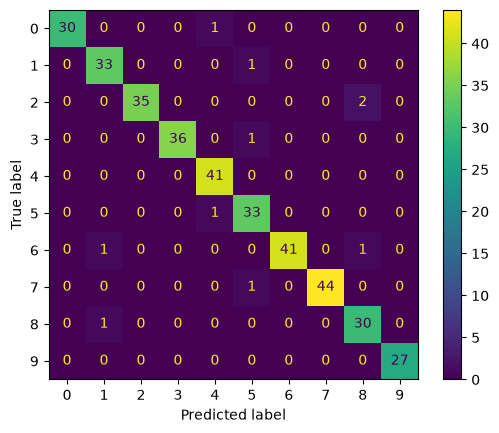

In [132]:
best_model2 = MLPClassifier(hidden_layer_sizes=(32, 32, 32, 32, 32, 32), max_iter=100, random_state=0)
best_model2.fit(X1_train, Y1_train)
bestModel_pred = best_model2.predict(X1_test)

cm = confusion_matrix(Y1_test, bestModel_pred, labels= data_d.target_names)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=data_d.target_names)

disp.plot()
plt.show() 